# Granularity Experiment

Notebook flow:
1. Oversampling comparison — pick best sampler per classifier
2. Define label schemes — severity-based class merging
3. Incremental granularity experiment — all n_classes, all models, full metrics
4. Sweet spot plots

## 0. Imports & CONFIG

In [33]:
# libraries
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import f1_score, recall_score, precision_score, make_scorer

import sys
sys.path.insert(0, str(Path('../..').resolve()))
from src.tokenizer import tokenize

# reproducibility
seed = 7524
np.random.seed(seed)

# project root
PROJECT_ROOT = Path().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# stratified 5-fold cv
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# TF-IDF config — consistent with cleaning pipeline
TFIDF_KWARGS = dict(
    ngram_range=(1, 2), min_df=1, max_df=0.95,
    sublinear_tf=True, norm='l2',
    analyzer='word', tokenizer=tokenize, token_pattern=None,
)

# macro scorers for all granularity levels
SCORERS = {
    'f1_macro':        make_scorer(f1_score,       average='macro', zero_division=0),
    'recall_macro':    make_scorer(recall_score,    average='macro', zero_division=0),
    'precision_macro': make_scorer(precision_score, average='macro', zero_division=0),
}

# class labels for reference
WOT_CLASSES  = {0:'Non-Toxic', 1:'Insults', 2:'Other Offensive Texts',
                3:'Hate and Harassment', 4:'Threats', 5:'Extremism'}
DOTA_CLASSES = {0:'Non-Toxic', 1:'Ego', 2:'Aggression', 3:'Impolite'}
print('CONFIG loaded.')

CONFIG loaded.


**World of Tanks**
| Class | Terminology |
|---|---|
| 0 | Non-Toxic |
| 1 | Insults and Flaming |
| 2 | Other Offensive Texts |
| 3 | Hate and Harassment |
| 4 | Threats |
| 5 | Extremism |

**Dota**
| Class | Label |
|---|---|
| 0 | Other (non-toxic) |
| 1 | Ego |
| 2 | Aggression |
| 3 | Impolite |

## 1. Oversampling Comparison (Binary)

In [34]:
# load train splits from cleaning notebook
train_wot  = pd.read_parquet(PROJECT_ROOT / "data/processed_data/wot/x_train.parquet")
train_dota = pd.read_parquet(PROJECT_ROOT / "data/processed_data/dota/x_train.parquet")

# oversamplers to compare
OVERSAMPLERS = {
    'None':             None,
    'RandomOverSampler': RandomOverSampler(random_state=seed),
    'SMOTE':             SMOTE(random_state=seed),
    'ADASYN':            ADASYN(random_state=seed),
}

# datasets for oversampler comparison
DATASETS = {
    'WoT':  (train_wot["message"],  train_wot["label"]),
    'Dota': (train_dota["message"], train_dota["label"]),
}

In [36]:
os_results = []

# classifiers to compare — each gets its own best oversampler
CLASSIFIERS = {
    'LogisticRegression': LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced', random_state=seed, n_jobs=1),
    'LinearSVC':          LinearSVC(C=1.0, max_iter=2000, class_weight='balanced', random_state=seed),
    'MultinomialNB':      MultinomialNB(),
}

for game, (X_tr, y_tr) in DATASETS.items():
    print(f'=== {game} ===')
    for clf_name, clf in CLASSIFIERS.items():
        for os_name, sampler in OVERSAMPLERS.items():
            steps = [('tfidf', TfidfVectorizer(**TFIDF_KWARGS))]
            if sampler is not None:
                steps.append(('oversample', sampler))
            steps.append(('clf', clone(clf)))

            res = cross_validate(ImbPipeline(steps), X_tr, y_tr, cv=cv, scoring=SCORERS, n_jobs=-1)
            scores = {k: res[f'test_{k}'].mean() for k in SCORERS}

            print(f'  {clf_name:<22} {os_name:<20} '
                  f'f1={scores["f1_macro"]:.4f}  '
                  f'recall={scores["recall_macro"]:.4f}  '
                  f'precision={scores["precision_macro"]:.4f}')
            os_results.append({'game': game, 'clf': clf_name, 'oversampler': os_name, **scores})

os_df = pd.DataFrame(os_results)
print('--- Best oversampler per (game, classifier) ---')
for game in DATASETS:
    for clf_name in CLASSIFIERS:
        best = os_df[(os_df['game'] == game) & (os_df['clf'] == clf_name)].sort_values('f1_macro', ascending=False).iloc[0]
        print(f'  {game} {clf_name:<22} → {best["oversampler"]}  f1={best["f1_macro"]:.4f}  recall={best["recall_macro"]:.4f}  precision={best["precision_macro"]:.4f}')

=== WoT ===
  LogisticRegression     None                 f1=0.5758  recall=0.6496  precision=0.5829
  LogisticRegression     RandomOverSampler    f1=0.5825  recall=0.6285  precision=0.5984
  LogisticRegression     SMOTE                f1=0.5743  recall=0.6426  precision=0.5858
  LogisticRegression     ADASYN               f1=0.5612  recall=0.6318  precision=0.5679
  LinearSVC              None                 f1=0.6136  recall=0.6024  precision=0.6542
  LinearSVC              RandomOverSampler    f1=0.5801  recall=0.6133  precision=0.6039
  LinearSVC              SMOTE                f1=0.5653  recall=0.6271  precision=0.5663
  LinearSVC              ADASYN               f1=0.4958  recall=0.5987  precision=0.5117
  MultinomialNB          None                 f1=0.2843  recall=0.2727  precision=0.4438
  MultinomialNB          RandomOverSampler    f1=0.4081  recall=0.6429  precision=0.3732
  MultinomialNB          SMOTE                f1=0.4197  recall=0.6468  precision=0.3877
  Multino

## 2. Define Potential Label Schemes

In [37]:
# Incremental severity-based splits — each step separates the next hardest class.
# Build from binary upward: merge similar first, split severe last.
# Labels must be 0-indexed and contiguous.

# n=2: binary
WOT_SCHEME_2 = {0: 0, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1}

# n=3: Non-Toxic / Insults+OtherOffensive (Mild toxicity) / Hate+Threats+Extremism (Severe toxicity)
WOT_SCHEME_3 = {0: 0, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2}

# n=4: Non-Toxic / Insults+OtherOffensive / Hate / Threats+Extremism
WOT_SCHEME_4 = {0: 0, 1: 1, 2: 1, 3: 2, 4: 3, 5: 3}

# n=5: Non-Toxic / Insults+OtherOffensive / Hate / Threats / Extremism
WOT_SCHEME_5 = {0: 0, 1: 1, 2: 1, 3: 2, 4: 3, 5: 4}

# n=6: identity
WOT_SCHEME_6 = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}

# Dota: no merge candidates found, but we can iterate just to experiment
# binary
DOTA_SCHEME_2 = {0: 0, 1: 1, 2: 1, 3: 1}

# n=3: Non-Toxic / Impolite (Mild toxicity) / Ego + Agression (Severe toxicity)
DOTA_SCHEME_3 = {0: 0, 1: 2, 2: 2, 3: 1}

# n=4: Non-Toxic / Ego / Agression / Impolite
DOTA_SCHEME_4 = {0: 0, 1: 1, 2: 2, 3: 3}

WOT_CLASS_NAMES = {
    2: ['Non-Toxic', 'Toxic'],
    3: ['Non-Toxic', 'Mild Toxicity', 'Severe Toxicity'],
    4: ['Non-Toxic', 'Insults/Other Offensive', 'Hate', 'Threats+Extremism'],
    5: ['Non-Toxic', 'Insults/Other Offensive', 'Hate', 'Threats', 'Extremism'],
    6: list(WOT_CLASSES.values()),
}

DOTA_CLASS_NAMES = {
    2: ['Non-Toxic', 'Toxic'],
    3: ['Non-Toxic', 'Mild Toxicity', 'Severe Toxicity'],
    4: ['Non-Toxic', 'Ego', 'Aggression', 'Impolite'],
}

WOT_SCHEMES  = {2: WOT_SCHEME_2, 3: WOT_SCHEME_3, 4: WOT_SCHEME_4,
                5: WOT_SCHEME_5, 6: WOT_SCHEME_6}
DOTA_SCHEMES = {2: DOTA_SCHEME_2, 3: DOTA_SCHEME_3, 4: DOTA_SCHEME_4}

print('Schemes defined.')
print('WoT schemes:', list(WOT_SCHEMES.keys()))
print('Dota schemes:', list(DOTA_SCHEMES.keys()))

Schemes defined.
WoT schemes: [2, 3, 4, 5, 6]
Dota schemes: [2, 3, 4]


## 3. Incremental Granularity Experiment

In [39]:
# classifiers 
CLASSIFIERS = {
    'LogisticRegression': LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced', random_state=seed, n_jobs=1),
    'LinearSVC':          LinearSVC(C=1.0, max_iter=2000, class_weight='balanced', random_state=seed),
}

In [40]:
def run_granularity_track(game, train, schemes):
    results = []

    for n_classes, scheme in schemes.items():
        # collapse fine-grained classes into n_classes using label scheme
        df = train.copy()
        df['label'] = df['label'].astype(int).map(scheme)

        # features and target for this granularity level
        X, y = df['message'], df['label']
        best_f1, best_name, best_rec, best_prec = -1, None, 0, 0

        # evaluate each classifier on this granularity level
        for clf_name, clf in CLASSIFIERS.items():
            pipe = Pipeline([
                ('tfidf', TfidfVectorizer(**TFIDF_KWARGS)),
                ('clf',   clone(clf)),
            ])

            # cross-validate and extract mean scores
            res    = cross_validate(pipe, X, y, cv=cv, scoring=SCORERS, n_jobs=-1)
            scores = {k: res[f'test_{k}'].mean() for k in SCORERS}

            print(f'{game} n={n_classes} {clf_name:<22} '
                  f'f1={scores["f1_macro"]:.4f}  '
                  f'recall={scores["recall_macro"]:.4f}  '
                  f'precision={scores["precision_macro"]:.4f}')

            # update best model if current has higher f1
            if scores['f1_macro'] > best_f1:
                best_f1, best_name = scores['f1_macro'], clf_name
                best_rec, best_prec = scores['recall_macro'], scores['precision_macro']

        # store best result for this granularity level
        results.append({
            'game':                 game,
            'n_classes':            n_classes,
            'best_model':           best_name,
            'best_f1_macro':        round(best_f1,   4),
            'best_recall_macro':    round(best_rec,  4),
            'best_precision_macro': round(best_prec, 4),
        })
        print(f'  → best: {best_name} (f1={best_f1:.4f})\n')

    return pd.DataFrame(results)


# run granularity track for both games
print('=== WoT incremental ===')
wot_results  = run_granularity_track('WoT',  train_wot,  WOT_SCHEMES)

print('\n=== Dota incremental ===')
dota_results = run_granularity_track('Dota', train_dota, DOTA_SCHEMES)

# summary tables
print('\nWoT:');  print(wot_results.to_string(index=False))
print('\nDota:'); print(dota_results.to_string(index=False))

=== WoT incremental ===
WoT n=2 LogisticRegression     f1=0.9185  recall=0.8965  precision=0.9461
WoT n=2 LinearSVC              f1=0.9255  recall=0.9087  precision=0.9454
  → best: LinearSVC (f1=0.9255)

WoT n=3 LogisticRegression     f1=0.7293  recall=0.7477  precision=0.7270
WoT n=3 LinearSVC              f1=0.7399  recall=0.7077  precision=0.7869
  → best: LinearSVC (f1=0.7399)

WoT n=4 LogisticRegression     f1=0.6266  recall=0.6883  precision=0.6216
WoT n=4 LinearSVC              f1=0.6569  recall=0.6403  precision=0.7015
  → best: LinearSVC (f1=0.6569)

WoT n=5 LogisticRegression     f1=0.6037  recall=0.6777  precision=0.6312
WoT n=5 LinearSVC              f1=0.6234  recall=0.6009  precision=0.7095
  → best: LinearSVC (f1=0.6234)

WoT n=6 LogisticRegression     f1=0.5758  recall=0.6496  precision=0.5829
WoT n=6 LinearSVC              f1=0.6136  recall=0.6024  precision=0.6542
  → best: LinearSVC (f1=0.6136)


=== Dota incremental ===
Dota n=2 LogisticRegression     f1=0.9234  re

## 4. Sweet Spot Plots

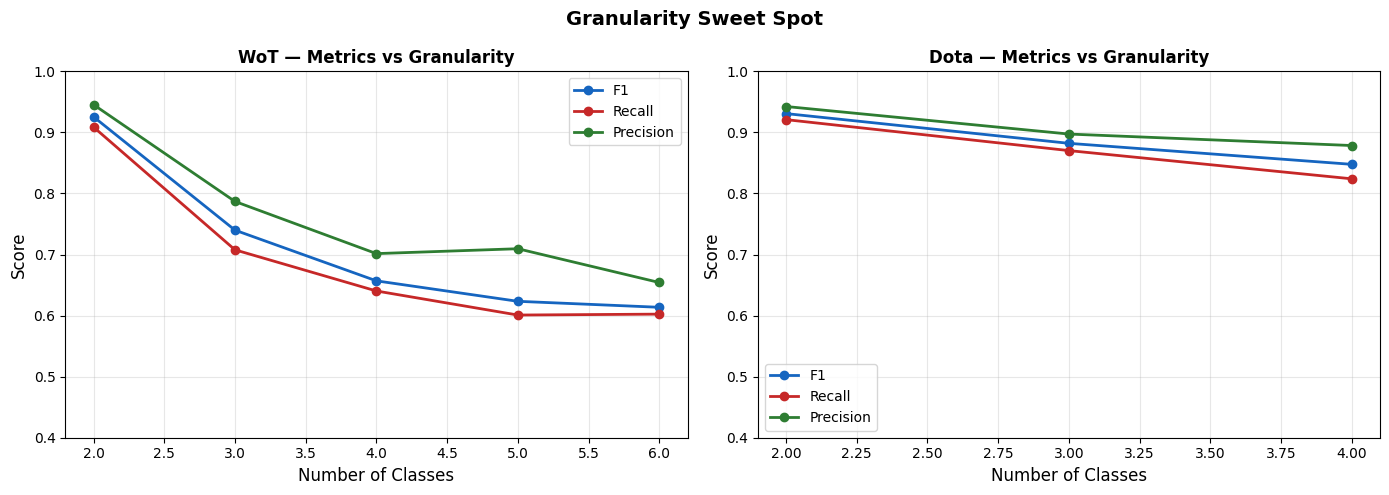

In [41]:
# combine both games for unified plotting
all_results = pd.concat([wot_results, dota_results], ignore_index=True)
games       = all_results['game'].unique()

# metric lines — column, label, color
metrics = [
    ('best_f1_macro',        'F1',        '#1565C0'),
    ('best_recall_macro',    'Recall',    '#C62828'),
    ('best_precision_macro', 'Precision', '#2E7D32'),
]

fig, axes = plt.subplots(1, len(games), figsize=(7 * len(games), 5))
if len(games) == 1:
    axes = [axes]

for ax, game in zip(axes, games):
    gdf = all_results[all_results['game'] == game]

    # plot each metric line
    for col, label, color in metrics:
        ax.plot(gdf['n_classes'], gdf[col],
                marker='o', linewidth=2, color=color, label=label)

    ax.set_xlabel('Number of Classes', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'{game} — Metrics vs Granularity', fontweight='bold')
    ax.legend()
    ax.set_ylim(0.4, 1.0)
    ax.grid(True, alpha=0.3)

plt.suptitle('Granularity Sweet Spot', fontweight='bold', fontsize=14)
plt.tight_layout()

# save to results
plt.savefig(PROJECT_ROOT / 'data/results/granularity_sweet_spot.png', dpi=150, bbox_inches='tight')
plt.show()
